# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
from functions import *

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [2]:
data = pd.read_csv("clustering_data_cleaned.csv", index_col = 'Loyalty#')
data.head()

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0


## Behavioral segmentation

In [3]:
behavioral_data = data[["Avg_Distance_per_flight" , "PctFlightsWithCompanions", "PctPointsSpent",
                        
                        "Pct_Spend_Month_1", "Pct_Spend_Month_2", "Pct_Spend_Month_3", "Pct_Spend_Month_4", "Pct_Spend_Month_5", 
                        "Pct_Spend_Month_6", "Pct_Spend_Month_7", "Pct_Spend_Month_8", "Pct_Spend_Month_9", "Pct_Spend_Month_10", 
                        "Pct_Spend_Month_11", "Pct_Spend_Month_12"]]

Total Spends per month will not be used as they become redundant when gathers with the percentages per month.

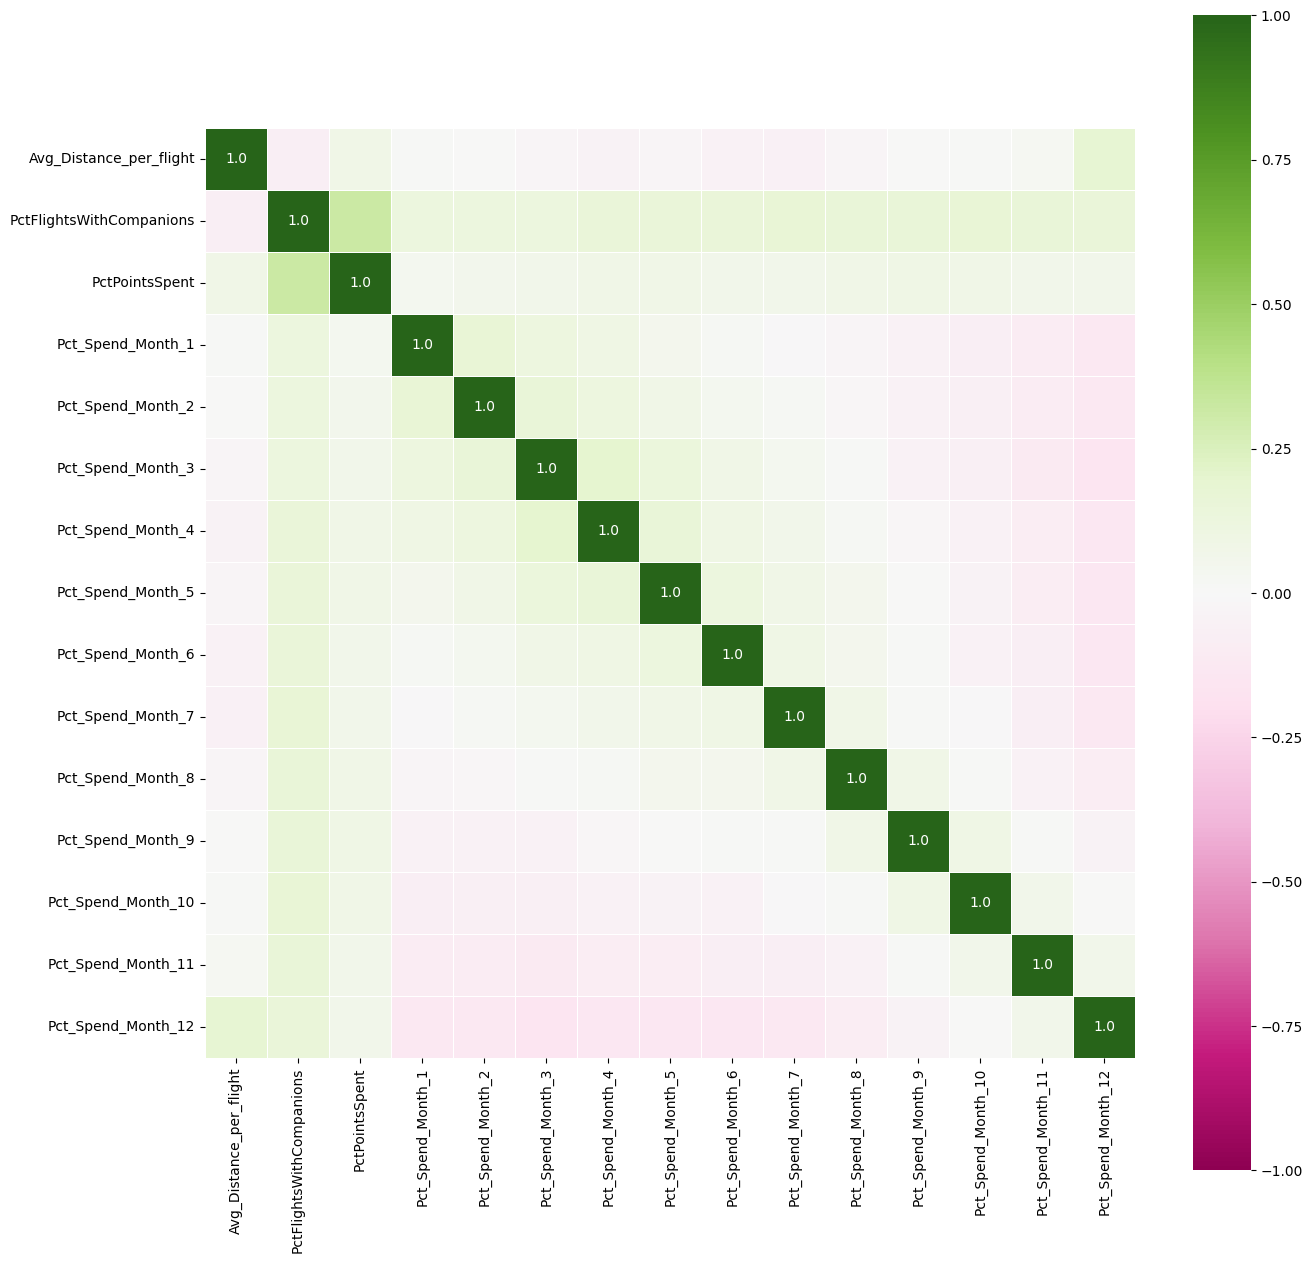

In [4]:
correlation_matrix(behavioral_data, 0.7, 15, 15)

It doesn't exist any high correlation between features, so all features will be kept.

In [5]:
behavioral_data.to_csv("../data/clustering_data/behavioral_data.csv")

In [6]:
behavioral_data = behavioral_data.copy()

In [7]:
behavioral_data

,Avg_Distance_per_flight,PctFlightsWithCompanions,PctPointsSpent,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12
Loyalty#,,,,,,,,,,,,,,,
100011,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100012,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100013,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100014,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100015,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999996,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999997,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695


In [8]:
behavioral_data_st_scl = StandardScaler().fit_transform(behavioral_data)
behavioral_data_mm_scl = MinMaxScaler().fit_transform(behavioral_data)
behavioral_data_rb_scl = RobustScaler().fit_transform(behavioral_data)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

### Behavioral Data

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

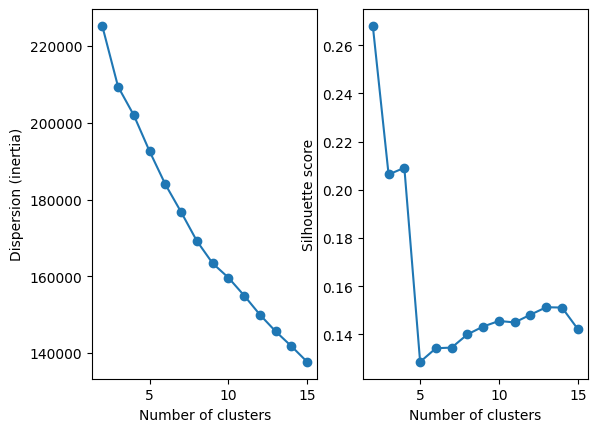

In [9]:
plot_inertia_and_silhouette(behavioral_data_st_scl)

In [10]:
kmeans_st_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_st_scl)
data['st_scaled_km_cluster3'] = kmeans_st_scl.predict(behavioral_data_st_scl)
behavioral_data['st_scaled_km_cluster3'] = kmeans_st_scl.predict(behavioral_data_st_scl)

### Hierarchichal - Ward

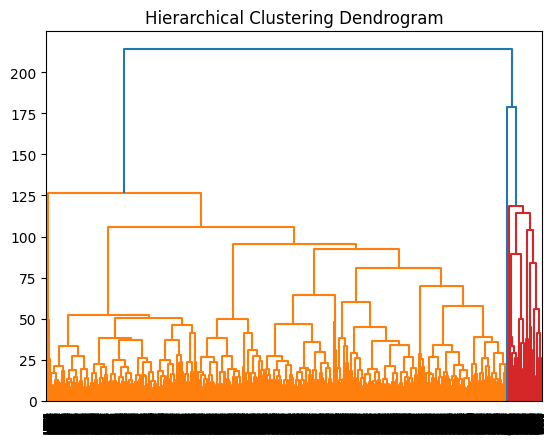

In [11]:
plot_dendrogram(behavioral_data_st_scl, 'ward')

In [12]:
data['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_st_scl)

behavioral_data['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

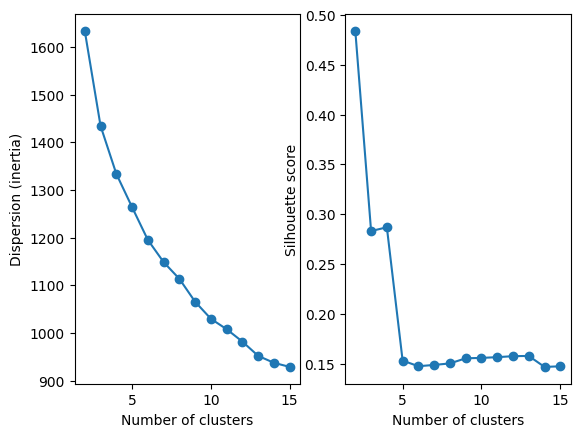

In [13]:
plot_inertia_and_silhouette(behavioral_data_mm_scl)

In [14]:
kmeans_mm_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_mm_scl)
data['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_mm_scl)
behavioral_data['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_mm_scl)

### Hierarchichal - Ward

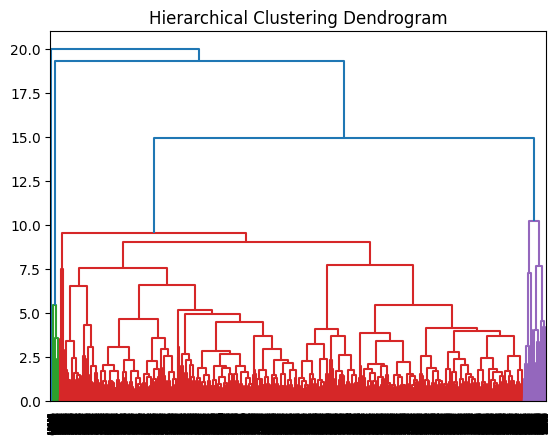

In [15]:
plot_dendrogram(behavioral_data_mm_scl, 'ward')

In [16]:
data['mm_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(behavioral_data_mm_scl)

behavioral_data['mm_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(behavioral_data_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

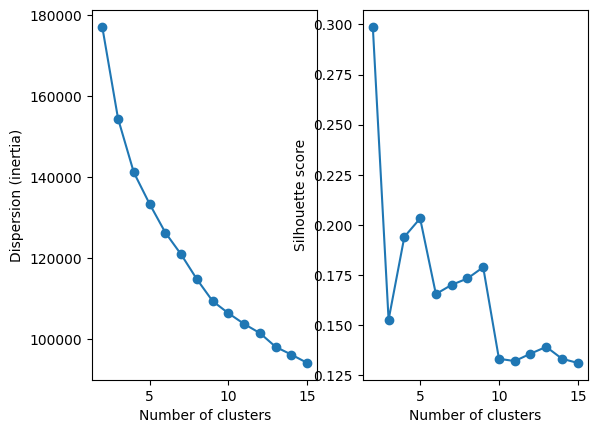

In [17]:
plot_inertia_and_silhouette(behavioral_data_rb_scl)

In [18]:
kmeans_rb_scl = KMeans(n_clusters=4, random_state=42).fit(behavioral_data_rb_scl)
data['rb_scaled_km_cluster4'] = kmeans_rb_scl.predict(behavioral_data_rb_scl)
behavioral_data['rb_scaled_km_cluster4'] = kmeans_rb_scl.predict(behavioral_data_rb_scl)

### Hierarchichal - Ward

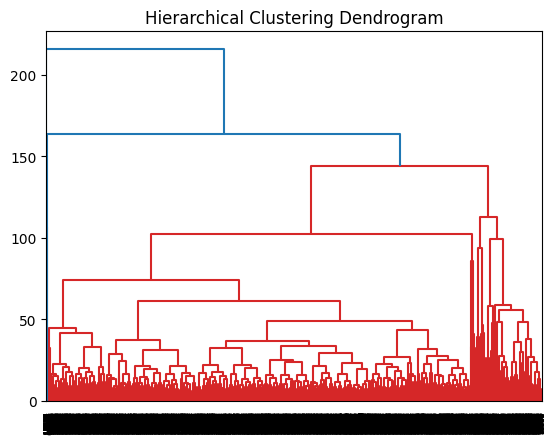

In [19]:
plot_dendrogram(behavioral_data_rb_scl, 'ward')

In [20]:
data['rb_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(behavioral_data_rb_scl)

behavioral_data['rb_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(behavioral_data_rb_scl)

# <span style="color:#0097b2">1. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization 1

In [21]:
clusters_km = ['st_scaled_km_cluster3', 'st_scaled_ward_cluster2',
               'mm_scaled_km_cluster3', 'mm_scaled_ward_cluster4',
               'rb_scaled_km_cluster4', 'rb_scaled_ward_cluster5']

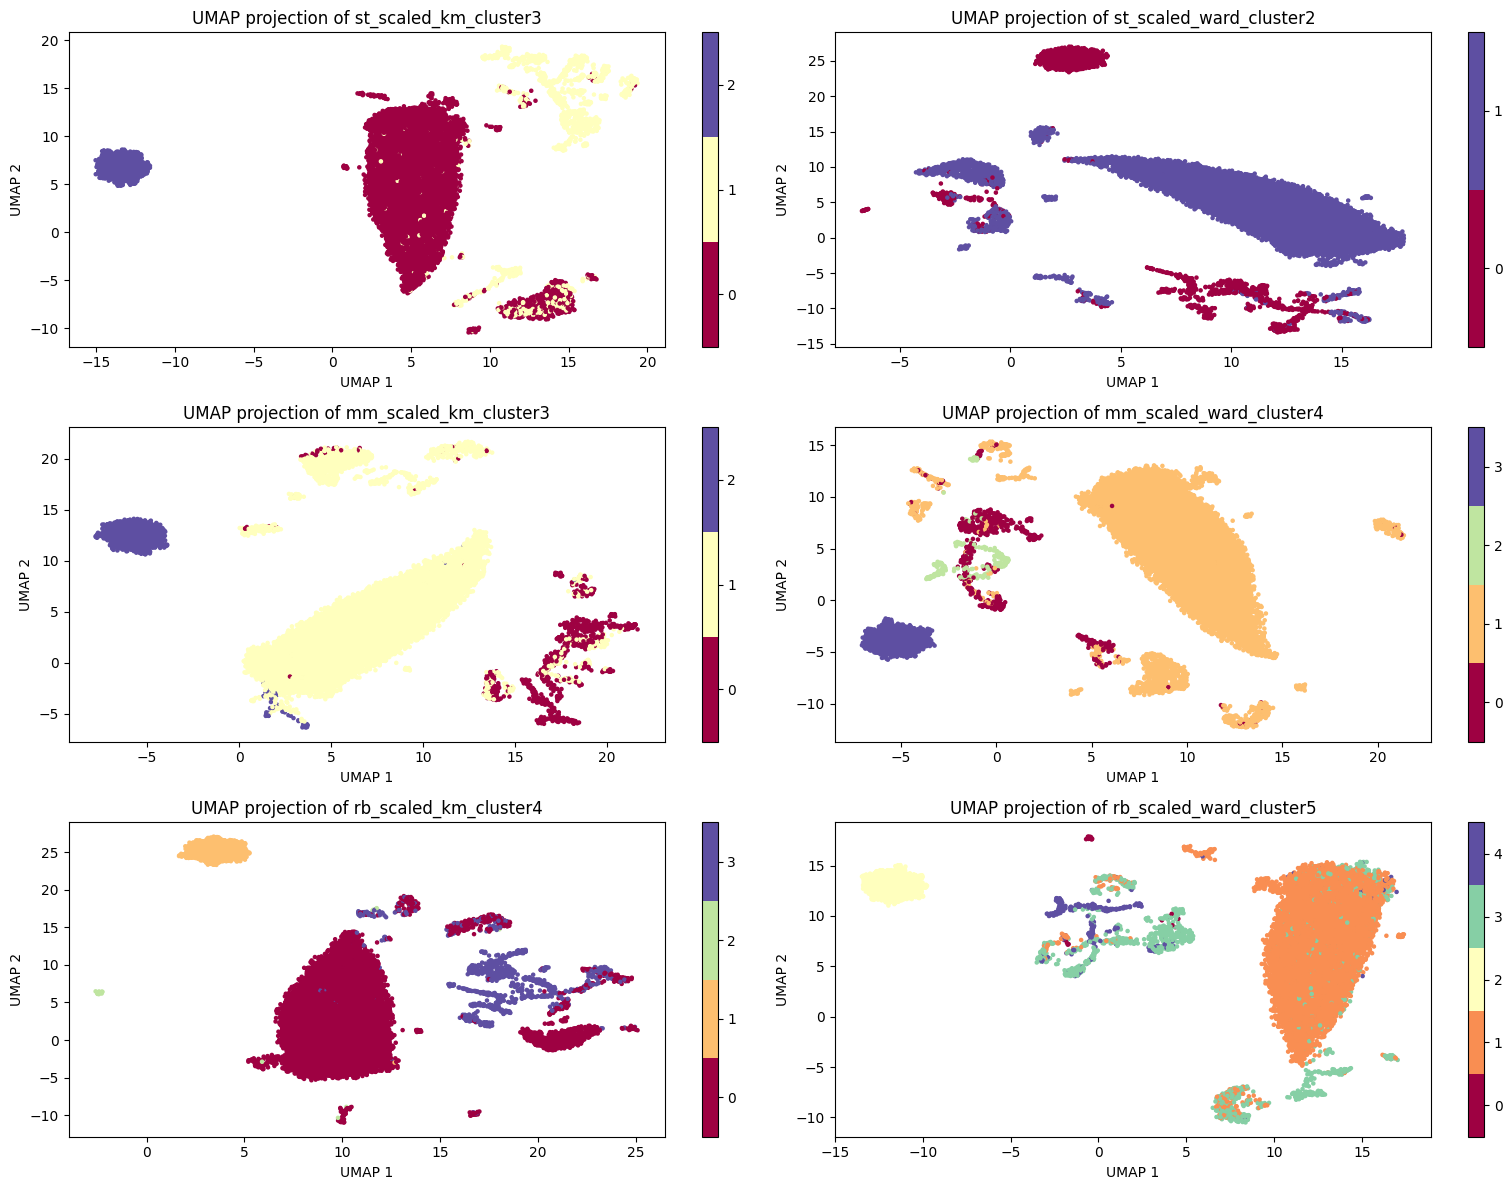

In [24]:
plot_umap_projections(behavioral_data, clusters_km, n_neighbors= 40, min_dist= 0.8)

In [25]:
groupby_mean(behavioral_data, 'st_scaled_km_cluster3', n_features= 14)

st_scaled_km_cluster3,0,1,2
Avg_Distance_per_flight,0.000514,0.000644,0.000499
PctFlightsWithCompanions,0.251722,0.274409,0.000000
PctPointsSpent,0.300319,0.337975,0.000000
Pct_Spend_Month_1,0.064649,0.011551,0.000000
Pct_Spend_Month_2,0.063083,0.011052,0.000000
Pct_Spend_Month_3,0.082505,0.009843,0.000000
Pct_Spend_Month_4,0.072202,0.009834,0.000000
Pct_Spend_Month_5,0.085299,0.012890,0.000000
Pct_Spend_Month_6,0.105256,0.018855,0.000000
Pct_Spend_Month_7,0.110267,0.028002,0.000000


- Cluster 2 - No Activity Customers

#### Cluster Extraction 1

In [26]:
# Filter the DataFrame based on cluster labels
no_activity = data[data['st_scaled_km_cluster3'] == 2]

In [27]:
no_activity

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster3,st_scaled_ward_cluster2,mm_scaled_km_cluster3,mm_scaled_ward_cluster4,rb_scaled_km_cluster4,rb_scaled_ward_cluster5
Loyalty#,,,,,,,,,,,,,,,,,,,,,
101356,25666.0,7482.64,0,0,2228.0,0,2015,11,1,0.0,...,0,0,1,0,2,0,2,3,1,2
102308,0.0,12866.89,0,0,44.0,0,2021,11,4,0.0,...,0,0,0,1,2,0,2,3,1,2
103352,51705.0,5555.49,0,0,281.0,1,2017,11,4,0.0,...,0,0,1,0,2,0,2,3,1,2
103383,11432.0,13466.92,0,0,245.0,1,2018,6,1,0.0,...,0,0,1,0,2,0,2,3,1,2
104739,22520.0,5498.94,0,0,232.0,1,2016,11,4,0.0,...,0,0,1,0,2,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997857,30817.0,3436.13,0,0,41.0,1,2019,6,3,0.0,...,0,1,0,0,2,0,2,3,1,2
997912,22828.0,16473.17,0,0,98.0,1,2016,8,4,0.0,...,1,0,1,0,2,0,2,3,1,2
999143,36305.0,4861.37,0,0,243.0,1,2018,7,1,0.0,...,0,0,1,0,2,0,2,3,1,2


In [28]:
# List of cluster labels to exclude
exclude_clusters = [2]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered1 = data[~data['st_scaled_km_cluster3'].isin(exclude_clusters)]

In [29]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster3,st_scaled_ward_cluster2,mm_scaled_km_cluster3,mm_scaled_ward_cluster4,rb_scaled_km_cluster4,rb_scaled_ward_cluster5
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,1,0,0,1,1,1,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,1,0,1,1,1,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,1,0,0,1,1,1,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,1,0,0,1,1,1,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,1,0,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,1,0,0,1,1,1,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,1,0,1,1,1,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,1,0,0,1,1,1,0,1


In [30]:
data_filtered1 = data_filtered1.iloc[:, :-6]
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [31]:
behavioral_data = behavioral_data.iloc[:, :-6]
behavioral_data

,Avg_Distance_per_flight,PctFlightsWithCompanions,PctPointsSpent,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12
Loyalty#,,,,,,,,,,,,,,,
100011,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100012,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100013,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100014,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100015,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999996,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999997,0.000499,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

In [32]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [55]:
data_filtered11 = data_filtered1.copy()
behavioral_data_1 = data_filtered11[behavioral_data.columns.to_list()]

In [56]:
behavioral_data_1_st_scl = StandardScaler().fit_transform(behavioral_data_1)
behavioral_data_1_mm_scl = MinMaxScaler().fit_transform(behavioral_data_1)
behavioral_data_1_rb_scl = RobustScaler().fit_transform(behavioral_data_1)

#### Cluster Modelling 2

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

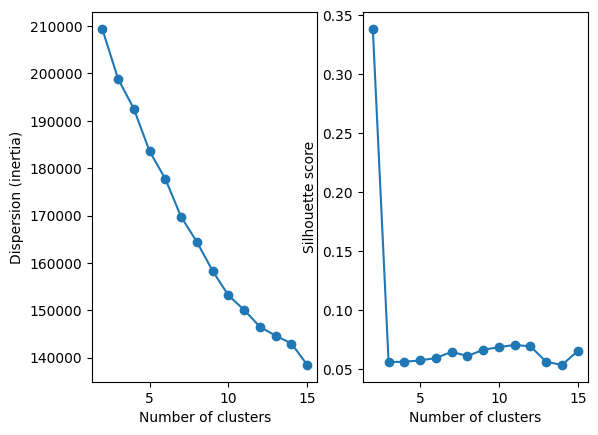

In [35]:
plot_inertia_and_silhouette(behavioral_data_1_st_scl)

In [57]:
kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_st_scl)
data_filtered11['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_1_st_scl)
behavioral_data_1['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_1_st_scl)

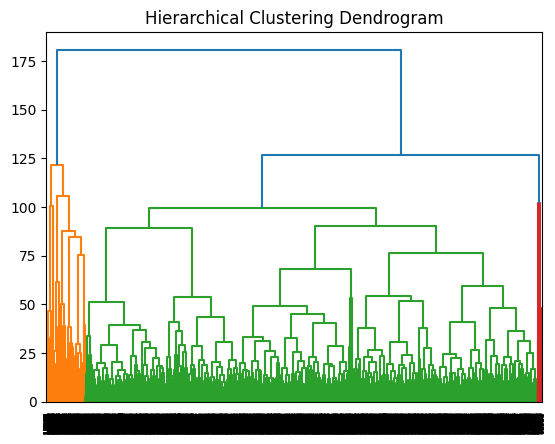

In [36]:
plot_dendrogram(behavioral_data_1_st_scl, 'ward')

In [58]:
data_filtered11['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_st_scl)

behavioral_data_1['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Min Max Scaling</h3>

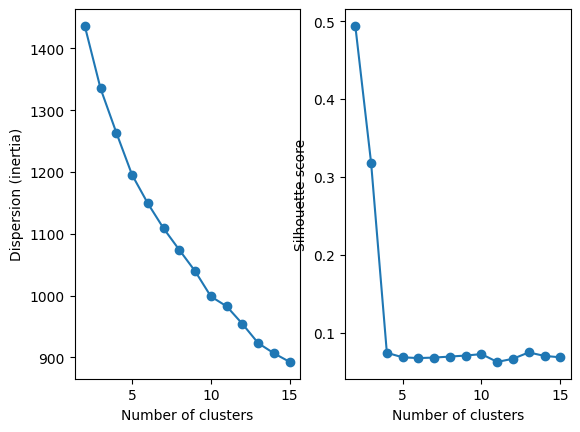

In [37]:
plot_inertia_and_silhouette(behavioral_data_1_mm_scl)

In [59]:
kmeans_mm_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_mm_scl)
data_filtered11['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_1_mm_scl)
behavioral_data_1['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_1_mm_scl)

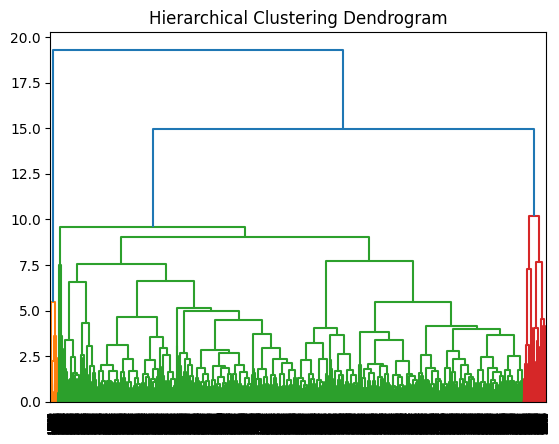

In [38]:
plot_dendrogram(behavioral_data_1_mm_scl, 'ward')

In [60]:
data_filtered11['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_mm_scl)


behavioral_data_1['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

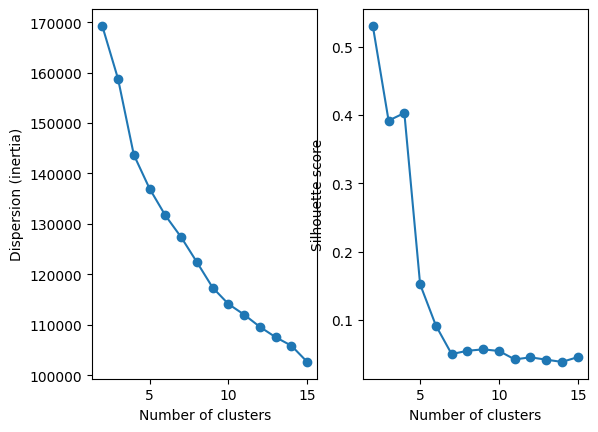

In [39]:
plot_inertia_and_silhouette(behavioral_data_1_rb_scl)

In [61]:
kmeans_rb_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_rb_scl)
data_filtered11['rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(behavioral_data_1_rb_scl)
behavioral_data_1['rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(behavioral_data_1_rb_scl)

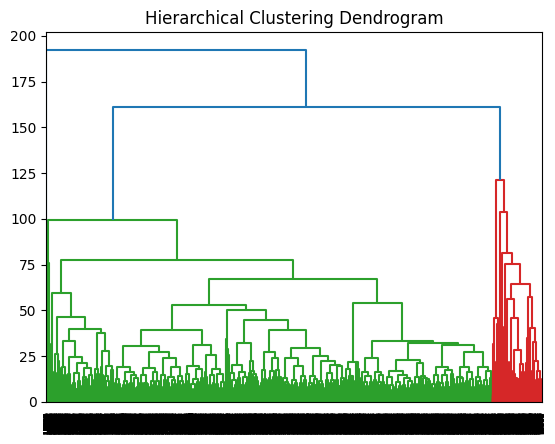

In [40]:
plot_dendrogram(behavioral_data_1_rb_scl, 'ward')

In [62]:
data_filtered11['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_rb_scl)

behavioral_data_1['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_rb_scl)

#### Cluster Visualization 2

In [63]:
cluster_filter1 = ["st_scaled_km_cluster2",	"st_scaled_ward_cluster2", 
                   "mm_scaled_km_cluster2", "mm_scaled_ward_cluster2",
                   "rb_scaled_km_cluster2",	"rb_scaled_ward_cluster2"]

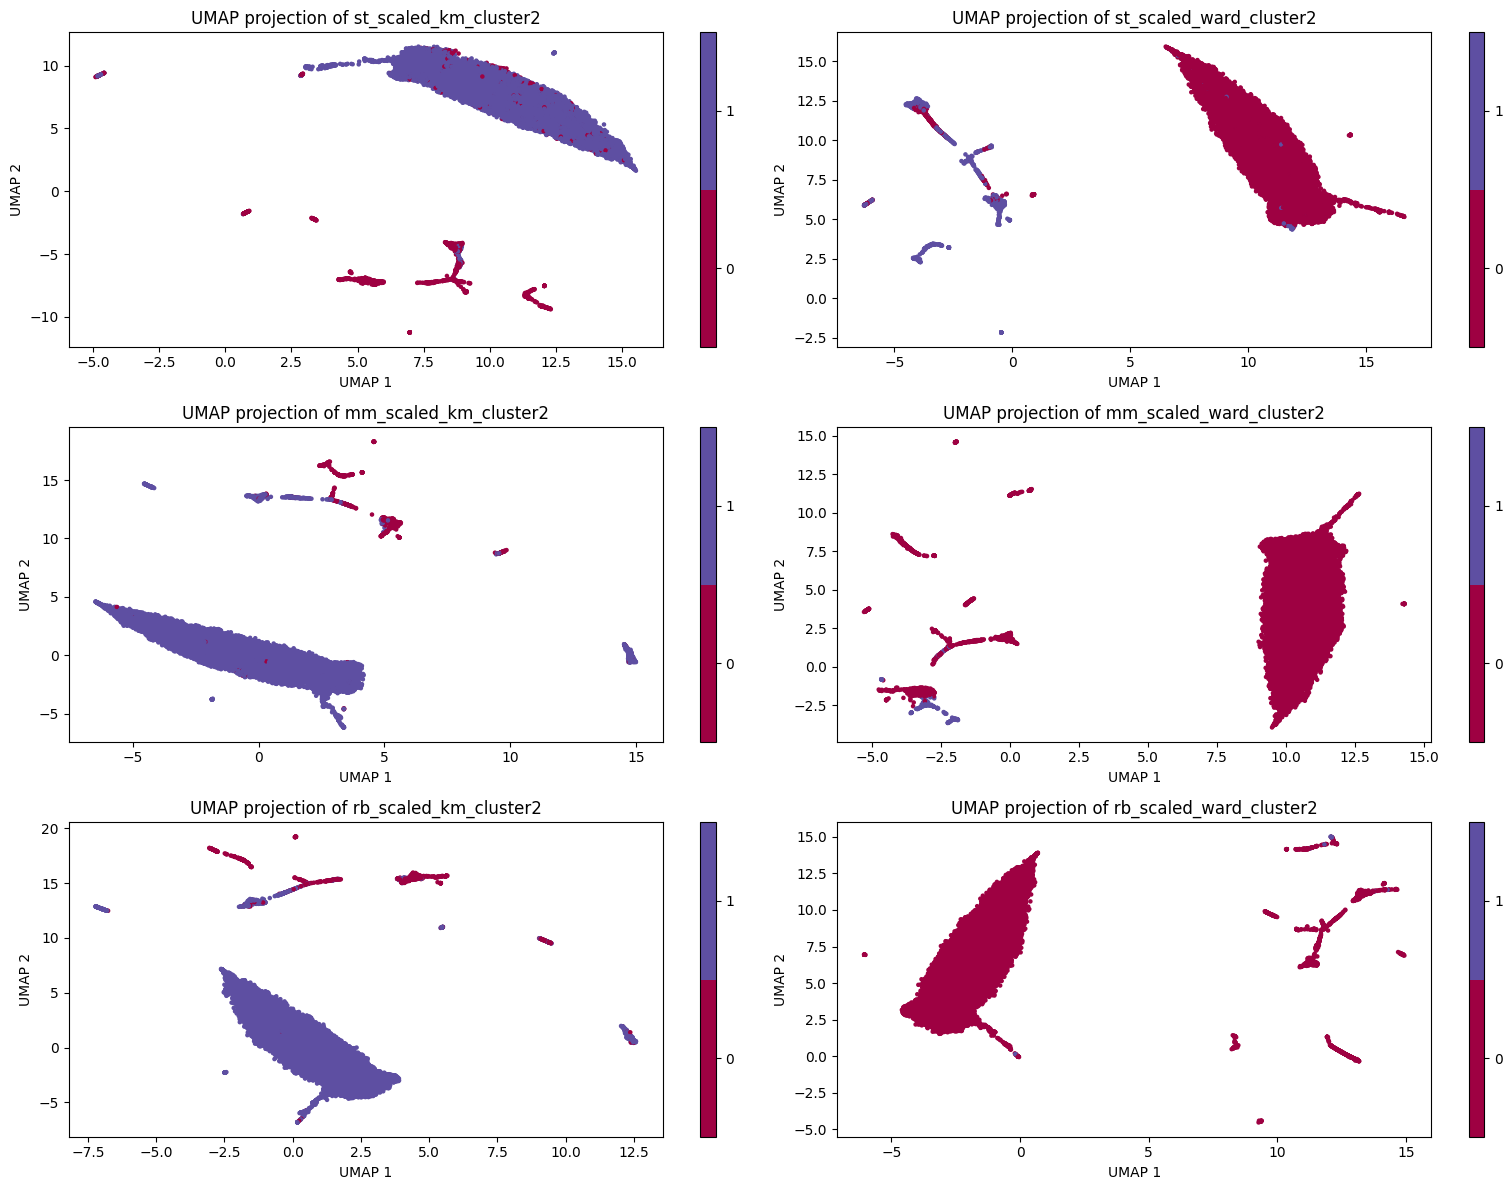

In [64]:
plot_umap_projections(behavioral_data_1, cluster_filter1, n_neighbors= 40, min_dist= 0.1)

In [ ]:
groupby_mean(behavioral_data_1, 'st_scaled_ward_cluster2', n_features= 14)

st_scaled_ward_cluster2,0,1
Avg_Distance_per_flight,0.000514,0.000692
PctFlightsWithCompanions,0.252232,0.276462
PctPointsSpent,0.299987,0.355017
Pct_Spend_Month_1,0.063658,0.004414
Pct_Spend_Month_2,0.062197,0.003066
Pct_Spend_Month_3,0.080896,0.003004
Pct_Spend_Month_4,0.070896,0.003096
Pct_Spend_Month_5,0.083865,0.004109
Pct_Spend_Month_6,0.103728,0.006253
Pct_Spend_Month_7,0.109258,0.010851


- Cluster 1 - Fly_from_9_to_12_month ( 85% spent in these months)

#### Cluster Extraction 2

In [69]:
# Filter the DataFrame based on cluster labels
_9_to_12_travelers = data_filtered11[data_filtered11['st_scaled_ward_cluster2'] == 1]
len(_9_to_12_travelers)

1207

In [70]:
# List of cluster labels to exclude
exclude_clusters = [1]

# Filter the original dataset to exclude rows with specified cluster labels
data_filter2 = data_filtered11[~data_filtered11['st_scaled_ward_cluster2'].isin(exclude_clusters)]

In [71]:
data_filter2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster2,st_scaled_ward_cluster2,mm_scaled_km_cluster2,mm_scaled_ward_cluster2,rb_scaled_km_cluster2,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,1,0,1,0,1,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,1,1,0,1,0,1,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,1,0,1,0,1,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,1,0,1,0,1,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,1,0,1,0,1,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,1,1,0,1,0,1,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,1,0,1,0,1,0,1,0


In [72]:
data_filter2 = data_filter2.iloc[:, :-6]
behavioral_data_1 = behavioral_data_1.iloc[:,:-6]

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

In [73]:
data_filter2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [74]:
data_filtered2 = data_filter2.copy()
behavioral_data_2 = data_filtered2[behavioral_data_1.columns.to_list()]

In [75]:
behavioral_data_2_st_scl = StandardScaler().fit_transform(behavioral_data_2)
behavioral_data_2_mm_scl = MinMaxScaler().fit_transform(behavioral_data_2)
behavioral_data_2_rb_scl = RobustScaler().fit_transform(behavioral_data_2)

#### Cluster Modelling 3

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

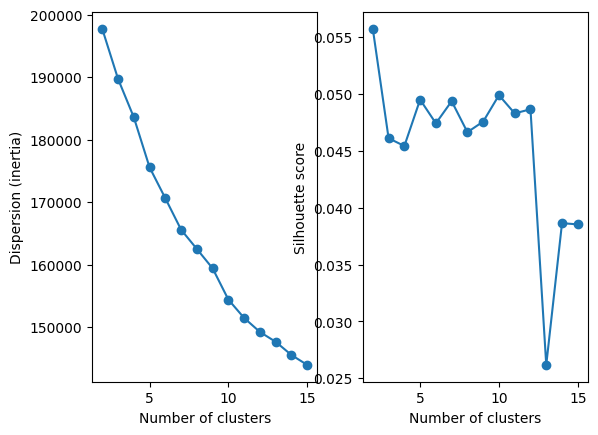

In [76]:
plot_inertia_and_silhouette(behavioral_data_2_st_scl)

In [86]:
kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_2_st_scl)
data_filtered2['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_2_st_scl)
behavioral_data_2['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_2_st_scl)

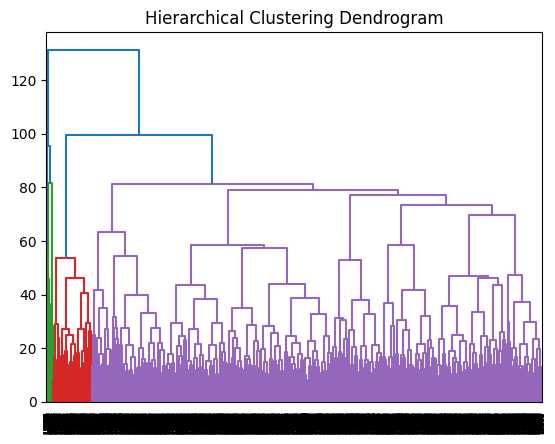

In [77]:
plot_dendrogram(behavioral_data_2_st_scl, 'ward')

In [87]:
data_filtered2['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_st_scl)

behavioral_data_2['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Min Max Scaling</h3>

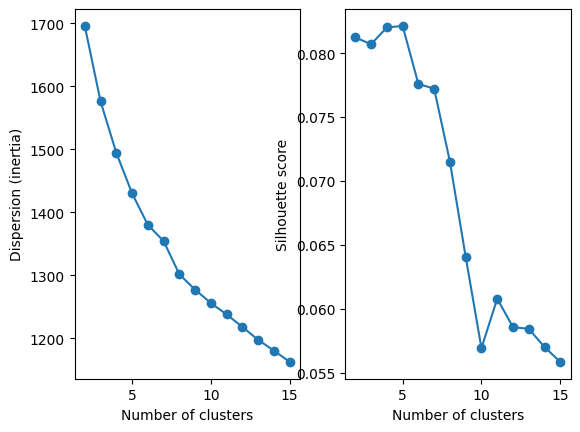

In [78]:
plot_inertia_and_silhouette(behavioral_data_2_mm_scl)

In [94]:
kmeans_mm_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_2_mm_scl)
data_filtered2['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_2_mm_scl)
behavioral_data_2['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_2_mm_scl)

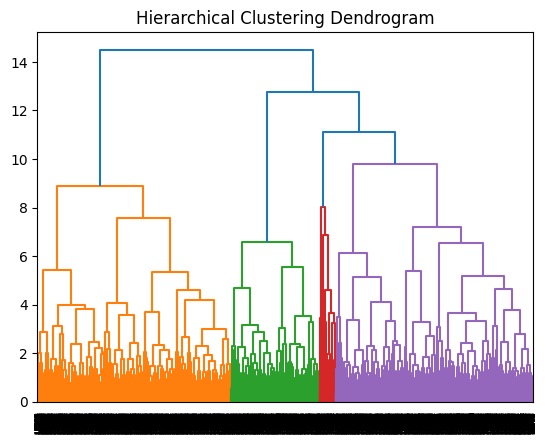

In [79]:
plot_dendrogram(behavioral_data_2_mm_scl, 'ward')

In [83]:
data_filtered2['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_mm_scl)

behavioral_data_2['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

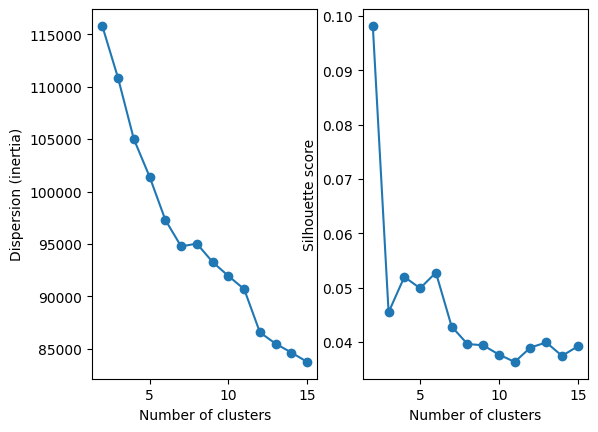

In [80]:
plot_inertia_and_silhouette(behavioral_data_2_rb_scl)

In [128]:
kmeans_rb_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_2_rb_scl)
data_filtered2['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(behavioral_data_2_rb_scl)
behavioral_data_2['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(behavioral_data_2_rb_scl)

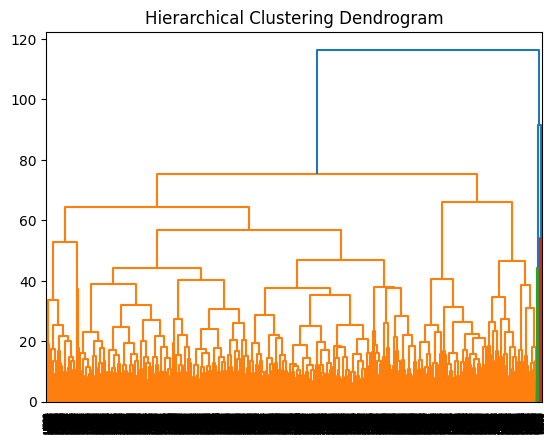

In [81]:
plot_dendrogram(behavioral_data_2_rb_scl, 'ward')

In [85]:
data_filtered2['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_rb_scl)

behavioral_data_2['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_rb_scl)

#### Cluster Visualization 2

In [129]:
cluster_filter1 = ["st_scaled_km_cluster2", "st_scaled_ward_cluster2",
                   'mm_scaled_km_cluster2', "mm_scaled_ward_cluster2",
                   "rb_scaled_km_cluster3", "rb_scaled_ward_cluster2"
                   ]

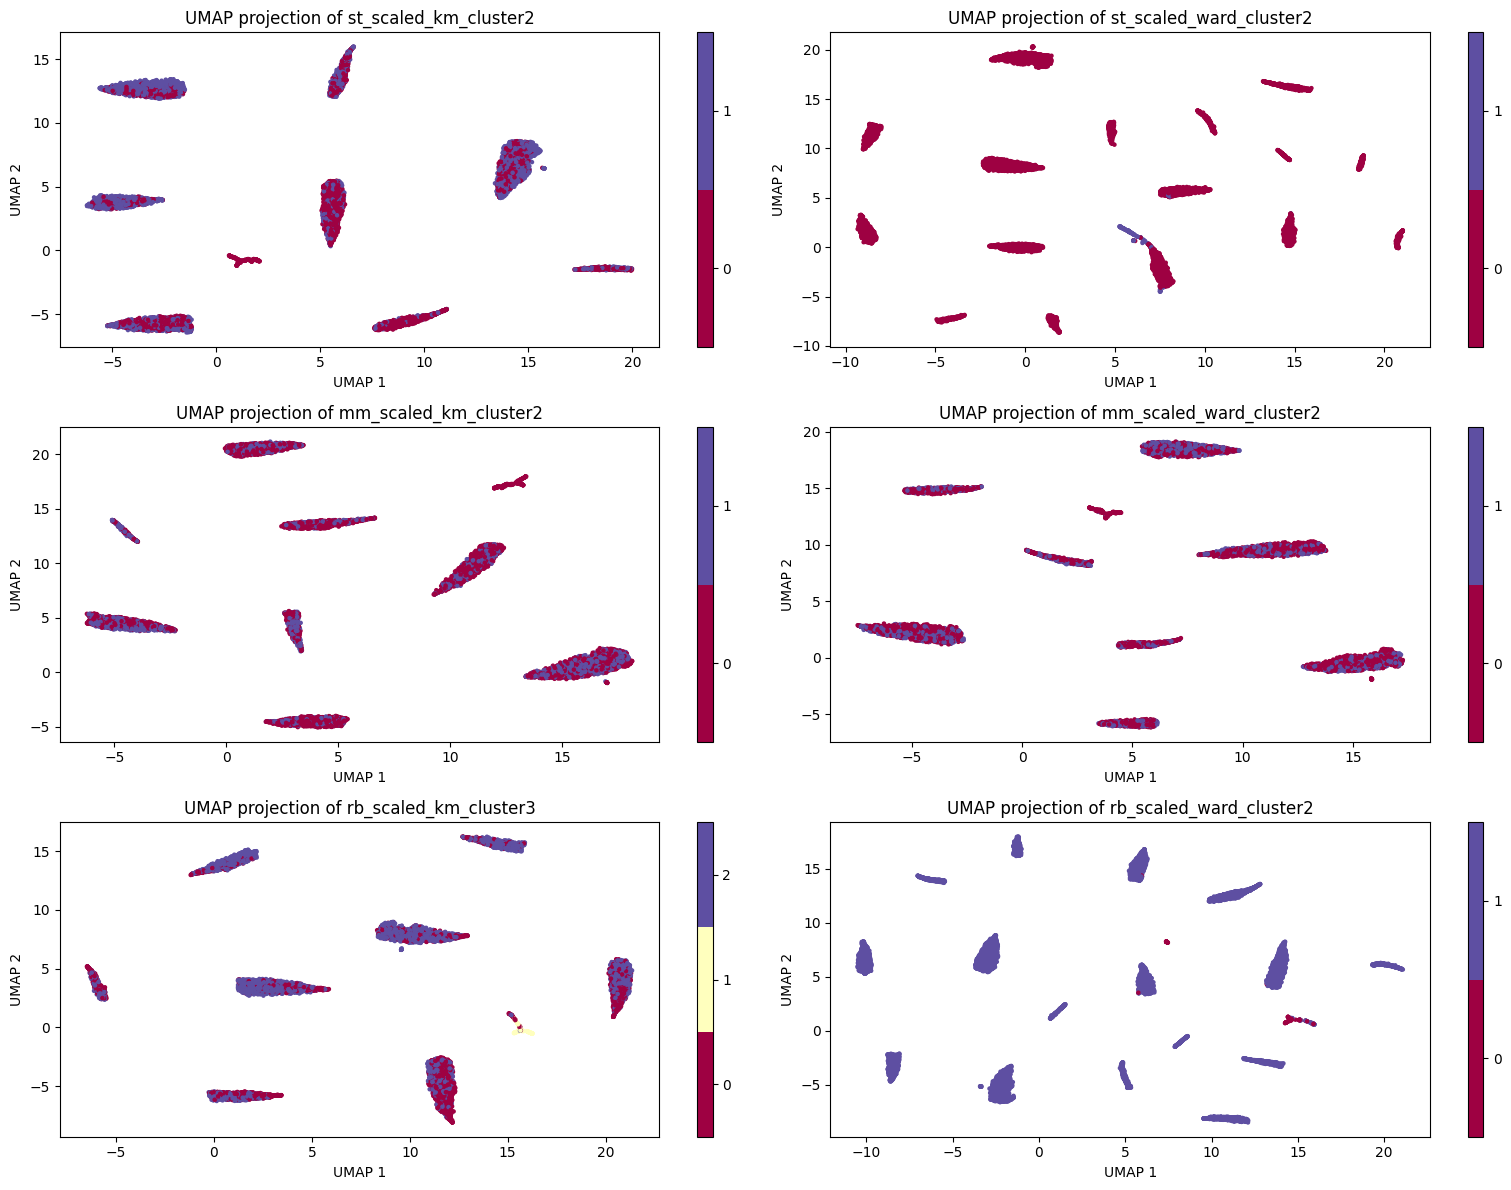

In [136]:
plot_umap_projections(behavioral_data_2, cluster_filter1, n_neighbors= 30, min_dist= 0.1)

In [142]:
groupby_mean(behavioral_data_2, 'rb_scaled_km_cluster3', n_features= 14)

rb_scaled_km_cluster3,0,1,2
Avg_Distance_per_flight,0.000613,0.000678,0.000448
PctFlightsWithCompanions,0.235705,0.294099,0.262133
PctPointsSpent,0.404559,0.234488,0.234074
Pct_Spend_Month_1,0.067988,0.519821,0.053416
Pct_Spend_Month_2,0.071294,0.354455,0.051586
Pct_Spend_Month_3,0.097334,0.077019,0.070430
Pct_Spend_Month_4,0.082681,0.030423,0.064010
Pct_Spend_Month_5,0.093982,0.009248,0.078606
Pct_Spend_Month_6,0.102651,0.005548,0.106025
Pct_Spend_Month_7,0.097967,0.000000,0.118279


Cluster 0 - Active Redeemers with Off-Season Travel

- Active user of rewards (36.7% points redeemed)

- No Seasonality

Cluster 1 - January and February travelers
 
- 85% of flights on the first two months

Cluster 2 - Holidays travelers

- 11% of their total spend on july, and 10% on june, august and december


#### Cluster Extraction 3 and 4 

In [143]:
# Filter the DataFrame based on cluster labels
active_redeemers = data_filtered2[data_filtered2['rb_scaled_km_cluster3'] == 0]

Jan_Feb_travelers = data_filtered2[data_filtered2['rb_scaled_km_cluster3'] == 1]

holiday_travelers = data_filtered2[data_filtered2['rb_scaled_km_cluster3'] == 2]

In [144]:
# List of cluster labels to exclude
exclude_clusters = [0,1,2]

# Filter the original dataset to exclude rows with specified cluster labels
data_filter3 = data_filtered2[~data_filtered2['rb_scaled_km_cluster3'].isin(exclude_clusters)]

In [145]:
data_filter3

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Marital_Married,Marital_Single,mm_scaled_km_cluster3,mm_scaled_ward_cluster2,rb_scaled_km_cluster3,rb_scaled_ward_cluster2,st_scaled_km_cluster2,st_scaled_ward_cluster2,mm_scaled_km_cluster2,rb_scaled_km_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,


# <span style="color:#0097b2">1. Cluster Extraction</span>
[Back to TOC](#toc)

In [146]:
data['segment'] = 'Unassigned'

data.loc[no_activity.index, 'segment'] = 'No_Activity'
data.loc[_9_to_12_travelers.index, 'segment'] = 'From_September_to_December_travelers'
data.loc[Jan_Feb_travelers.index, 'segment'] = 'Jan_Feb_travelers'
data.loc[active_redeemers.index, 'segment'] = 'Active_Redeemers'
data.loc[holiday_travelers.index, 'segment'] = 'Holiday_travelers'

In [147]:
data['segment'].value_counts()

segment
Holiday_travelers                       8430
Active_Redeemers                        5400
No_Activity                             1497
From_September_to_December_travelers    1207
Jan_Feb_travelers                        138
Name: count, dtype: int64

In [148]:
segment_dummies = pd.get_dummies(
    data['segment'],
    prefix='seg',
    dtype=int
)

In [149]:
data = pd.concat([data, segment_dummies], axis=1)

In [150]:
data.drop(columns=['segment'], inplace=True)

In [151]:
data = data.loc[:, ~data.columns.str.startswith(("st_", "mm_", "rb_"))]

In [152]:
data

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,seg_Active_Redeemers,seg_From_September_to_December_travelers,seg_Holiday_travelers,seg_Jan_Feb_travelers,seg_No_Activity
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,0,1,0,0,0,1,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,0,1,0,0,1,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,0,1,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,0,1,0,0,0,1,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,0,1,0,0,0,1,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,0,1,0,0,1,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,0,1,0,0,0,1,0,0


In [153]:
data.to_csv("../data/behvioral_segment_data.csv")